# Recurrent Neural Network Modeling - Unstructured Leaf Position Input

In [5]:

from sklearn.model_selection import train_test_split
# importing the sys module
import sys		 

# appending the directory of mod.py 
# in the sys.path list
sys.path.append("C:\\Users\\gfman\\Documents\\GitHub\\bachelor-thesis")	 

from data_creator import load_3D_unstructured

X, y = load_3D_unstructured()

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, random_state = 4)

In [6]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=X_train.shape[1:]))
model.add(LSTM(units=50))
model.add(Dense(units=1, activation = 'sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics = ["accuracy"])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

c:\Users\gfman\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.8262 - loss: 0.4915 - val_accuracy: 0.9208 - val_loss: 0.2715
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.8724 - loss: 0.3459 - val_accuracy: 0.9208 - val_loss: 0.2605
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.9106 - loss: 0.2631 - val_accuracy: 0.9044 - val_loss: 0.2610
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.9073 - loss: 0.2413 - val_accuracy: 0.9180 - val_loss: 0.2529
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.9320 - loss: 0.2078 - val_accuracy: 0.9235 - val_loss: 0.2229
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.9411 - loss: 0.1750 - val_accuracy: 0.9317 - val_loss: 0.1902
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.9408 - loss: 0.1676 - val_accuracy: 0.9208 - val_loss: 0.2234
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.9536 - loss: 0.1395 - val_accuracy: 0.

## Results

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
Testing ROC AUC 0.7321428571428571


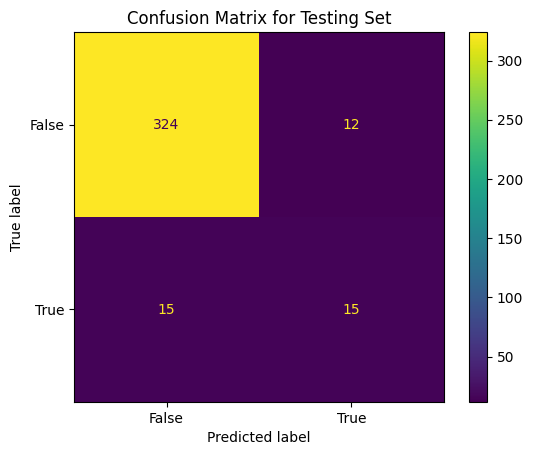

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay
preds_rnn = model.predict(X_test)
print("Testing ROC AUC", roc_auc_score(y_test, preds_rnn>0.5))
cm1 = ConfusionMatrixDisplay.from_predictions(y_test, preds_rnn>0.5)
cm1.ax_.set_title("Confusion Matrix for Testing Set")
plt.show()